# Point source model counts -- new data set

In [1]:
%reset -f
%run setup_notebook
%run pylib/tools dark date
from utilities.skymaps import AITfigure
from like3 import pixel_table as pt; reload(pt)
PixelTable = pt.PixelTable
from like3 import pointsource_info as psi; reload(psi)
PtSrcInfo = psi.PtsrcInfo

<h5 style="text-align:right; margin-right:15px"> 2026-05-18 14:29</h5>

### Load basic pixel table
Note that v5 no longer has the pointsource column<br>
Also the v5 PtSrcInfo object with all source counts

In [ ]:
pt = PixelTable('files/kerr/toby_v5.fits')
ptsrc = PtSrcInfo('files/kerr/toby_v5',)

*** Need new code for point source info in v5+ FITS files
Loaded pixel table from "files/kerr/toby_v5.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Loaded columns ['names', 'spectra', 'entries_per_band', 'nameidx', 'healpixidx', 'pscounts'] from files/kerr/toby_ptsrcs_v5.npz
Total number of pixels: 18,265,372
Loaded meta data describing 43 bands from files/kerr/toby_v5.pickle


In [3]:
show(f'### Load a source model using Fermi catalog version {(version:="v40")} and create point source bands ')
show(f' Selected source is {(name:="3C454.3")}, with a cone size of {(cone_size:=0.1)} degrees')
from like3.sourcelist import SourceModel
sm = SourceModel.from_fermi_catalog(name, version=version, cone_size=cone_size)
print(sm)
idx = ptsrc.get_source_indeces( sm); 
print(f""" Souurce index {idx}, total counts {ptsrc.spectra[:,idx].sum():,.0f}""")
src = sm[0]
center = src.skydir.galactic; 
print(src.skydir.icrs)


### Load a source model using Fermi catalog version v40 and create point source bands 

Selected source is 3C454.3, with a cone size of 0.1 degrees

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
SourceModel: @3C454.3 (v40) 1 sources with 2 free parameters
 Souurce index [7134], total counts 283,453
<SkyCoord (ICRS): (ra, dec) in deg
    (343.49371338, 16.14990044)>


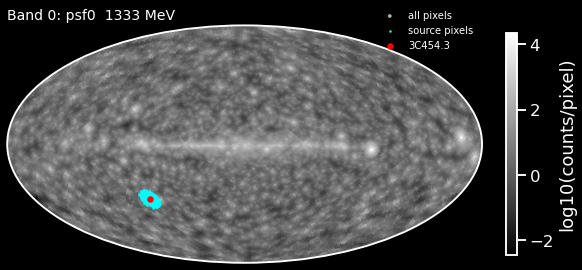

In [4]:
from matplotlib import legend


def ait_band_plot(self, band_index, 
                  source_model:SourceModel, fig=None,
                  colorbar=True, legend=True):

    from utilities.skymaps import AITfigure

    source_index = self.get_source_indeces( source_model)
    src = source_model[0]
    center = src.skydir.galactic; 

    band = self.create_ptband(source_index, band_index)
    pixdirs =band.healpix_to_skycoord(band.table.pixel_id)
    all_pix = self.get_band_pixel_counts(band.meta)

    ait =  AITfigure(fig=fig, figsize=(8,4))
    ait.title(f'Band {band_index}: {band.meta.event_type}  {(band.meta.energy)} MeV', 
                            fontsize=14, x=0, horizontalalignment='left')
    ait.scatter(band.healpix_to_skycoord(all_pix.index),  
                label='all pixels',  c=np.log10(all_pix.counts), cmap='gray', s=5)
    if colorbar:
        cb = ait.colorbar(label='log10(counts/pixel)', shrink=0.8)
        # cb.set_label('log10(counts/pixel)',) # why doesn't this work?
    ait.scatter(pixdirs, label='source pixels', color='cyan', s=1)
    ait.scatter(center, label=name, color='red', s=25)
    if legend:
        ait.legend(fontsize=10, bbox_to_anchor=(1., 1.1), loc='upper right', frameon=False)
    

ait_band_plot(ptsrc, 0, sm)

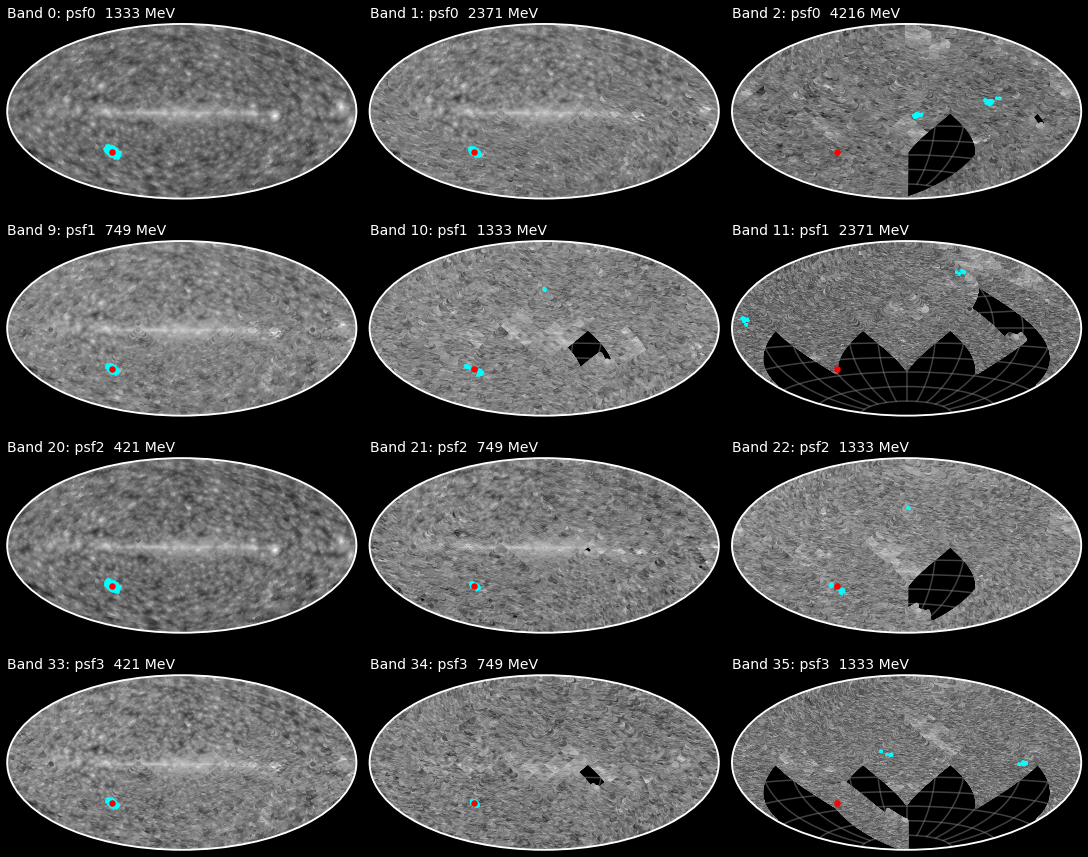

In [5]:
fig = plt.figure(figsize=(15,12))
sfigs = fig.subfigures(nrows=4, ncols=3)
for band_index, sfig in zip([0,1,2,9,10,11,20,21,22,33,34,35], sfigs.flatten()):
    ait_band_plot(ptsrc, band_index, sm, fig=sfig, colorbar=False, legend=False)
plt.show()

---
# Study the effective PSF for the source in each band, and how it compares with mine

In [69]:

def PSFplot(self, band_index, source_name,  
            *,ax=None):
    
    from astropy_healpix import HEALPix
    from contextlib import redirect_stdout

    meta_row =self.meta.iloc[band_index]
    pixel_area = HEALPix(meta_row.nside).pixel_area.value
    mypsf =  PSFlist().get_psf(meta_row.event_type, meta_row.energy)
    r68 = mypsf.r68


    fig,ax = plt.subplots(figsize=(4,4)) if ax is None else (ax.figure, ax)
    ax.text(0.05, 0.05, rf'R68=${r68:.2f}^\circ$', transform=ax.transAxes, ha='left', va='center', fontsize=12)

    t = np.linspace(0,4.5*r68,50)  
    ax.plot(t/r68, mypsf(t), label='psf table', color='orange') 
    
    for name in np.atleast_1d(source_name):
        with redirect_stdout(None):
            src = SourceModel.from_fermi_catalog(name, version=version, cone_size=cone_size)
        assert len(src)==1, f'Multiple sources found for {name} with cone size {cone_size} deg. Try reducing the cone size.'
        center = src[0].skydir.galactic
        source_index = self.get_source_indeces( src)
        band = self.create_ptband(source_index, band_index)
        pixdirs =band.healpix_to_skycoord(band.table.pixel_id)
        pix_counts = band.table.counts
        total_counts = self.spectra[band_index,source_index]
        seps = center.separation(pixdirs).deg/r68
    
        ax.scatter(seps, pix_counts/total_counts/pixel_area, 
                   s=5, label=name) 
    peak = mypsf(0)
    ax.set(yscale='log', xlim=(0,4.5), ylim=(peak/1e4,peak*1.2), xlabel='Separation / R68', ylabel='PSF (sr$^{-1}$)')
    ax.legend(fontsize=12, loc='upper right', frameon=False)
    ax.set_title(f'Band {band_index}: {meta_row.event_type}  {(meta_row.energy)} MeV', fontsize=14)
    return fig

# PSFplot(ptsrc, 0, ['Geminga', '3C454.3', 'Vela Pulsar']);

### Plot the counts in each pixel as a function of separation from the source position

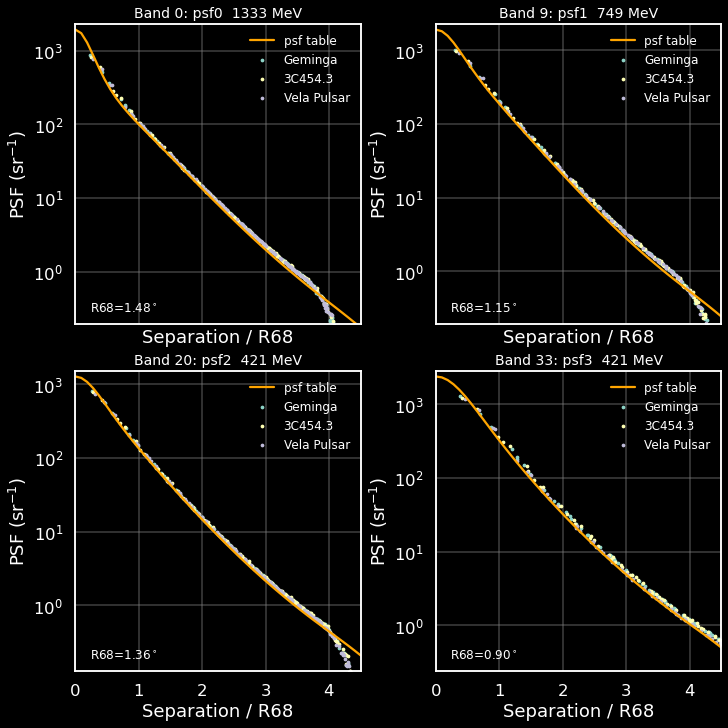

In [71]:
show(f'### Plot the counts in each pixel as a function of separation from the source position')

fig, axx = plt.subplots(nrows=2, ncols=2, figsize=(10,10), sharex=True, )
for band_index, ax in zip([0,9,20,33], axx.flatten()):
    PSFplot(ptsrc, band_index, ['Geminga', '3C454.3', 'Vela Pulsar'], ax=ax);
plt.show()

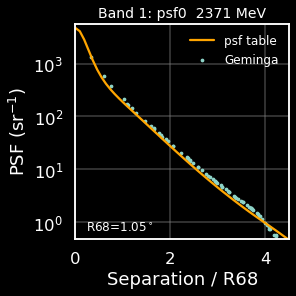

In [77]:
PSFplot(ptsrc, 1, ['Geminga', ]);

---
# Check the total number of unique pixels

In [ ]:
total_pix = 0
for idx, row in ptsrc.meta.iterrows():
    print(idx, row.event_type, row.energy, end=' ')
    bpc = ptsrc.get_band_pixel_counts(row)
    print(len(bpc), max(bpc.pixel_id), 12*row.nside**2)
    total_pix += len(bpc)
    
print(f"""Total pixels across all bands: {total_pix:,}""")

0 psf0 1333 49152 49151 49152
1 psf0 2371 49142 49151 49152
2 psf0 4216 179779 180404 196608
3 psf0 7498 139695 144472 196608
4 psf0 13335 86726 97992 196608
5 psf0 23713 59843 72059 786432
6 psf0 42169 27796 34947 786432
7 psf0 74989 12009 15664 786432
8 psf1 421 12288 12287 12288
9 psf1 749 49148 49151 49152
10 psf1 1333 192056 196463 196608
11 psf1 2371 494757 597767 786432
12 psf1 4216 234853 425754 786432
13 psf1 7498 158390 370759 3145728
14 psf1 13335 59442 174105 3145728
15 psf1 23713 23814 76835 3145728
16 psf1 42169 10393 33629 3145728
17 psf1 74989 4739 14417 3145728
18 psf2 133 3072 3071 3072
19 psf2 237 12288 12287 12288
20 psf2 421 49152 49151 49152
21 psf2 749 49096 49151 49152
22 psf2 1333 181850 196427 196608
23 psf2 2371 373076 583204 786432
24 psf2 4216 276413 676075 3145728
25 psf2 7498 98525 341872 3145728
26 psf2 13335 40534 175309 12582912
27 psf2 23713 16016 76762 12582912
28 psf2 42169 7311 36143 12582912
29 psf2 74989 3162 15402 12582912
30 psf3 74 768 767 768

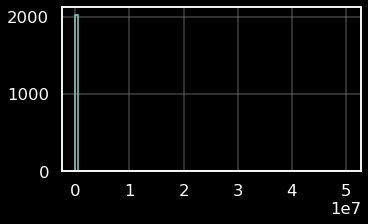

In [ ]:
plt.hist(bpc.pixel_id, histtype='step', bins=np.linspace(0,12*row.nside**2,100));

In [ ]:
self = ptsrc
sl = row['slice']
band_pixels = self.healpixidx[sl]
band_counts = self.pscounts[sl]
np.unique(band_pixels, return_counts=False)

array([   50,    51,    62, ..., 14951, 14976, 14977], shape=(2029,), dtype=uint32)

In [ ]:
for band_index in range(len(ptsrc.meta)):
    band = ptsrc.create_ptband(idx, band_index)                
    print(f'{band_index:4d}, {band}', end=' ')
    all_pix = ptsrc.get_band_pixel_counts(band_index)
    print(len(all_pix), 12*band.nside**2)

   0, PtBand(source=7134, key=(0, 4), pixels=149) 0 49152 49152
   1, PtBand(source=7134, key=(0, 5), pixels=88) 1 49142 49152
   2, PtBand(source=7134, key=(0, 6), pixels=179) 2 179779 196608
   3, PtBand(source=7134, key=(0, 7), pixels=81) 3 139695 196608
   4, PtBand(source=7134, key=(0, 8), pixels=34) 4 86726 196608
   5, PtBand(source=7134, key=(0, 9), pixels=23) 5 59843 786432
   6, PtBand(source=7134, key=(0, 10), pixels=5) 6 27796 786432
   7, PtBand(source=7134, key=(0, 11), pixels=0) 7 12009 786432
   8, PtBand(source=7134, key=(1, 2), pixels=66) 8 12288 12288
   9, PtBand(source=7134, key=(1, 3), pixels=101) 9 49148 49152
  10, PtBand(source=7134, key=(1, 4), pixels=116) 10 192056 196608
  11, PtBand(source=7134, key=(1, 5), pixels=187) 11 494757 786432
  12, PtBand(source=7134, key=(1, 6), pixels=61) 12 234853 786432
  13, PtBand(source=7134, key=(1, 7), pixels=59) 13 158390 3145728
  14, PtBand(source=7134, key=(1, 8), pixels=20) 14 59442 3145728
  15, PtBand(source=7134, 

In [ ]:
ptsrc.meta

,event_type,emin,emax,nside,entries,energy,slice
0,psf0,1000,1778,64,1082215,1333,"slice(0, 1082215, None)"
1,psf0,1778,3162,64,623364,2371,"slice(1082215, 1705579, None)"
2,psf0,3162,5623,128,1235626,4216,"slice(1705579, 2941205, None)"
3,psf0,5623,10000,128,574227,7498,"slice(2941205, 3515432, None)"
4,psf0,10000,17782,128,252779,13335,"slice(3515432, 3768211, None)"
5,psf0,17782,31622,256,190905,23713,"slice(3768211, 3959116, None)"
6,psf0,31622,56234,256,87303,42169,"slice(3959116, 4046419, None)"
7,psf0,56234,100000,256,37107,74989,"slice(4046419, 4083526, None)"
8,psf1,316,562,32,474238,421,"slice(4083526, 4557764, None)"
9,psf1,562,1000,64,731833,749,"slice(4557764, 5289597, None)"


In [ ]:
for iband in range(len(ptsrc.meta)):
    print(iband, ptsrc.meta.iloc[iband].event_type, ptsrc.meta.iloc[iband].energy, end=' ')
    band = ptsrc.create_ptband(idx, iband)
    print(len(band.table), 12*band.nside**2)

0 psf0 1333 149 49152
1 psf0 2371 88 49152
2 psf0 4216 179 196608
3 psf0 7498 81 196608
4 psf0 13335 34 196608
5 psf0 23713 23 786432
6 psf0 42169 5 786432
7 psf0 74989 0 786432
8 psf1 421 66 12288
9 psf1 749 101 49152
10 psf1 1333 116 196608
11 psf1 2371 187 786432
12 psf1 4216 61 786432
13 psf1 7498 59 3145728
14 psf1 13335 20 3145728
15 psf1 23713 11 3145728
16 psf1 42169 5 3145728
17 psf1 74989 1 3145728
18 psf2 133 76 3072
19 psf2 237 99 12288
20 psf2 421 142 49152
21 psf2 749 59 49152
22 psf2 1333 82 196608
23 psf2 2371 98 786432
24 psf2 4216 89 3145728
25 psf2 7498 38 3145728
26 psf2 13335 25 12582912
27 psf2 23713 12 12582912
28 psf2 42169 2 12582912
29 psf2 74989 0 12582912
30 psf3 74 76 768
31 psf3 133 62 3072
32 psf3 237 74 12288
33 psf3 421 99 49152
34 psf3 749 147 196608
35 psf3 1333 169 786432
36 psf3 2371 130 3145728
37 psf3 4216 57 3145728
38 psf3 7498 21 3145728
39 psf3 13335 21 12582912
40 psf3 23713 10 50331648
41 psf3 42169 7 50331648
42 psf3 74989 0 50331648


In [ ]:
show(f"""### Determine flux ratio for each pixel vs the separation from the source""")
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
src = sm[0]
center = src.skydir.galactic; 
print(src.skydir.icrs)
show(f""" Select band index {(band_index:=18)}, {(band:=bands[band_index])} for the source, and get the pixel directions""")
pixdirs =band.healpix_to_skycoord(band.table.pixel_id)#.to_string(precision=3)#.separation(center).deg

### Determine flux ratio for each pixel vs the separation from the source

<SkyCoord (ICRS): (ra, dec) in deg
    (343.49371338, 16.14990044)>


Select band index 18, PtBand(source=7134, key=(2, 1), pixels=99) for the source, and get the pixel directions

In [ ]:
band.skycoord_to_healpix(center), band.table.sort_values('counts', ascending=False).head()

(np.int64(8541),
     pixel_id       counts  other_counts
 55      8541  8386.468532     39.699264
 8       5128  4576.556924     63.826529
 57      8543  2904.665365     64.757193
 2       5122  2026.669027     43.187664
 49      8535  1826.692602     30.944900)

In [ ]:
band.nside, 12*band.nside**2, band.table.counts.sum()

(32, 12288, np.float64(29268.03526954731))

In [ ]:
count_df = pd.DataFrame(
    dict(name =ptsrc.names,   counts = ptsrc.spectra.sum(axis=0).round(0))
)     
count_df.sort_values('counts',ascending=False).head()

,name,counts
6889,FL16Y J0835.3-4510,3649060.0
6874,FL16Y J0633.9+1746,1138873.0
6861,FL16Y J0534.5+2201,528151.0
7008,FL16Y J1709.7-4429,451178.0
7097,FL16Y J2021.5+4026,383770.0


In [ ]:
show(f"""#### Get and plot all of the pixels for this band""")

#### Get and plot all of the pixels for this band

In [ ]:
ptsrc.get_band_pixel_counts(

,pixel_id,counts
0,0,159.151899
1,1,71.838837
2,2,106.473561
3,3,44.079949
4,4,41.574535
...,...,...
49147,49147,196.081702
49148,49148,96.920426
49149,49149,122.423973
49150,49150,264.091001


### Compare Kerr point-source data with your PSF calculation

PtBand coverage: 43 / 43 bands


,event_type,emin,emax,has_ptband,kerr_total,ptband_total,delta_total,frac_total
0,psf0,1000,1778,True,90.012316,90.024141,0.011826,0.000131
1,psf0,1778,3162,True,48.968749,48.995342,0.026593,0.000543
2,psf0,3162,5623,True,24.443452,23.721676,-0.721776,-0.029528
3,psf0,5623,10000,True,12.279663,11.624770,-0.654892,-0.053331
4,psf0,10000,17782,True,6.230312,4.712426,-1.517885,-0.243629
5,psf0,17782,31622,True,3.125722,1.159612,-1.966111,-0.629010
6,psf0,31622,56234,True,1.619232,0.705550,-0.913682,-0.564269
7,psf0,56234,100000,True,0.839767,0.144938,-0.694829,-0.827407
8,psf1,316,562,True,248.367844,248.353366,-0.014477,-0.000058
9,psf1,562,1000,True,154.482164,154.496057,0.013893,0.000090


/tmp/ipykernel_257384/246530369.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


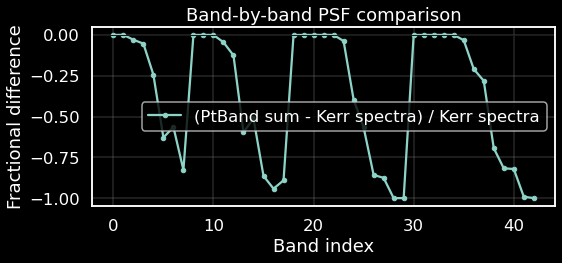

In [ ]:
# Build per-band/source counts from the PtBand pixel tables and compare to Kerr spectra.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _source_sums_from_ptband(ptband):
    tbl = ptband.table
    if len(ptband.source_indices) == 1 and 'counts' in tbl.columns:
        return np.array([float(tbl['counts'].sum())])
    cols = [f'counts_{s}' for s in ptband.source_indices]
    return np.array([float(tbl[c].sum()) for c in cols])


source_indices = np.asarray(idx, dtype=int)
kerr_spectra = np.asarray(ptsrc.spectra)[:, source_indices]  # (n_band, n_src)
meta = ptsrc.meta.reset_index(drop=True).copy()

# Rebuild with all bands so comparison coverage is complete.
bands_all = ptsrc.create_all_ptbands(source_indices, include_empty=True)
ptband_sums = np.full_like(kerr_spectra, np.nan, dtype=float)
for b in bands_all:
    ptband_sums[int(b.band_index), :] = _source_sums_from_ptband(b)

meta['kerr_total'] = kerr_spectra.sum(axis=1)
meta['ptband_total'] = np.nansum(ptband_sums, axis=1)
meta['has_ptband'] = np.isfinite(ptband_sums).all(axis=1)
meta['delta_total'] = np.where(meta['has_ptband'], meta['ptband_total'] - meta['kerr_total'], np.nan)
meta['frac_total'] = np.where(
    meta['has_ptband'] & (meta['kerr_total'] > 0),
    meta['delta_total'] / meta['kerr_total'],
    np.nan,
)

# Optional: add your PSF calculation as an array named my_psf_calc with shape (n_band, n_src).
if 'my_psf_calc' in globals():
    my_psf = np.asarray(my_psf_calc, dtype=float)
    if my_psf.shape != kerr_spectra.shape:
        raise ValueError(f'my_psf_calc shape {my_psf.shape} must match {kerr_spectra.shape}')
    meta['my_psf_total'] = my_psf.sum(axis=1)
    meta['my_psf_minus_kerr'] = meta['my_psf_total'] - meta['kerr_total']
    meta['my_psf_frac'] = np.where(meta['kerr_total'] > 0, meta['my_psf_minus_kerr'] / meta['kerr_total'], np.nan)

print(f'PtBand coverage: {meta.has_ptband.sum()} / {len(meta)} bands')

display_cols = ['event_type', 'emin', 'emax', 'has_ptband', 'kerr_total', 'ptband_total', 'delta_total', 'frac_total']
if 'my_psf_total' in meta.columns:
    display_cols += ['my_psf_total', 'my_psf_minus_kerr', 'my_psf_frac']

display(meta[display_cols].round(6))

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
valid = meta['has_ptband']
ax.plot(meta.index[valid], meta.loc[valid, 'frac_total'], '.-', label='(PtBand sum - Kerr spectra) / Kerr spectra')
if 'my_psf_frac' in meta.columns:
    ax.plot(meta.index, meta['my_psf_frac'], '.-', label='(My PSF - Kerr spectra) / Kerr spectra')
ax.axhline(0.0, color='k', lw=1)
ax.set_xlabel('Band index')
ax.set_ylabel('Fractional difference')
ax.set_title('Band-by-band PSF comparison')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()